In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Ready tools")

Ready tools


In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scipy

   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ---------------------------------------- 0.3/37.3 MB ? eta -:--:--
    --------------------------------------- 0.5/37.3 MB 1.7 MB/s eta 0:00:22
   - -------------------------------------- 1.0/37.3 MB 2.0 MB/s eta 0:00:19
   - -------------------------------------- 1.3/37.3 MB 1.7 MB/s eta 0:00:22
   - -------------------------------------- 1.8/37.3 MB 1.9 MB/s eta 0:00:20
   -- ------------------------------------- 2.1/37.3 MB 1.9 MB/s eta 0:00:19
   --- ------------------------------------ 3.1/37.3 MB 2.3 MB/s eta 0:00:16
   --- ------------------------------------ 3.4/37.3 MB 2.3 MB/s eta 0:00:15
   --- ------------------------------------ 3.7/37.3 MB 2.2 MB/s eta 0:00:16
   ---- ----------------------------------- 3.9/37.3 MB 2.1 MB/s eta 0:00:16
   ----- ---------------------------------- 4.7/37.3 MB 2.2 MB/s eta 0:00:15
   ----- -----------


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: c:\Users\HP\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [3]:
df = pd.read_csv('../data/ethiopia.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [4]:
print("Shape of the data (rows, columns):", df.shape)

Shape of the data (rows, columns): (4108, 12)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         4108 non-null   int64  
 1   DOY          4108 non-null   int64  
 2   T2M          4108 non-null   float64
 3   T2M_MAX      4108 non-null   float64
 4   T2M_MIN      4108 non-null   float64
 5   T2M_RANGE    4108 non-null   float64
 6   PRECTOTCORR  4108 non-null   float64
 7   RH2M         4108 non-null   float64
 8   WS2M         4108 non-null   float64
 9   WS2M_MAX     4108 non-null   float64
 10  PS           4108 non-null   float64
 11  QV2M         4108 non-null   float64
dtypes: float64(10), int64(2)
memory usage: 385.3 KB


In [6]:
df.isnull().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64

In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000


In [8]:
# 1. Convert YEAR and DOY to a datetime column
df["DATE"] = pd.to_datetime(df["YEAR"].astype(str) + df["DOY"].astype(str), format="%Y%j")

# 2. Extract Month for seasonal analysis
df["MONTH"] = df["DATE"].dt.month

# 3. Replace NASA's -999 sentinel value with actual NaN (Not a Number)
df.replace(-999, np.nan, inplace=True)

print("Dates converted and -999 values replaced with NaN.")

Dates converted and -999 values replaced with NaN.


In [9]:
# 1. Check and drop duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
df.drop_duplicates(inplace=True)

# 2. Describe numeric columns
display(df.describe())

Duplicate rows found: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,MONTH
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046




Duplicate rows may introduce bias into statistical summaries and visualizations.

The dataset is checked for duplicate observations using:
- duplicated row counts
- row removal if duplicates exist

The number of removed duplicates is documented below.

In [10]:
# Calculate percentage of missing values
missing_percentage = (df.isna().sum() / len(df)) * 100
print(missing_percentage[missing_percentage > 0])

Series([], dtype: float64)


In [11]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Compute Z-scores
z_scores = (df[cols_to_check] - df[cols_to_check].mean()) / df[cols_to_check].std()

# Count rows where absolute Z-score > 3
outliers = (z_scores.abs() > 3).sum()
print("Outlier count per column:")
print(outliers)

Outlier count per column:
T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64


Rows with absolute Z-scores greater than 3 are flagged as potential outliers.

Extreme climate observations may represent:
- genuine climate events
- sensor anomalies
- recording errors


In [16]:
threshold = len(df.columns) * 0.7
df.dropna(thresh=threshold, inplace=True)
df.ffill(inplace=True)
df.to_csv('../data/ethiopia_clean.csv', index=False)

print("Data successfully cleaned and exported!")


Data successfully cleaned and exported!


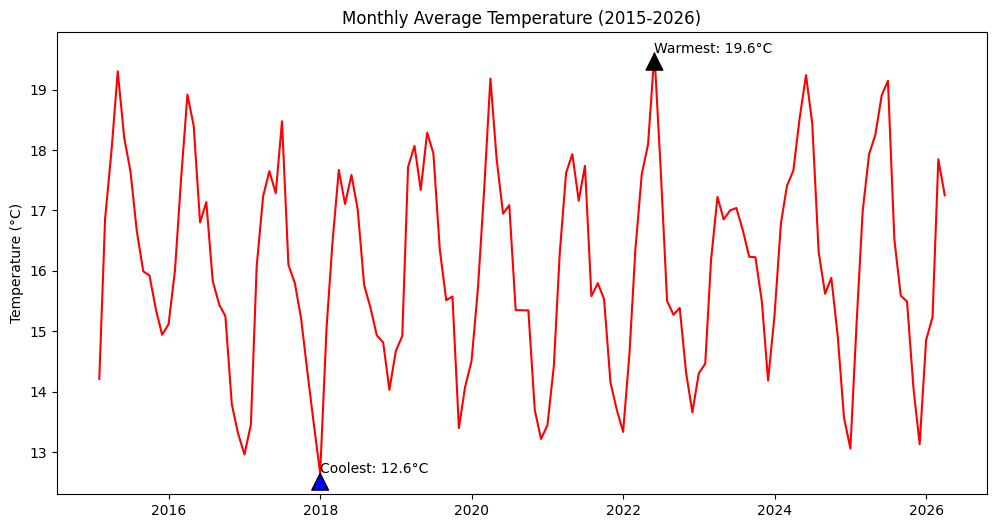

In [18]:
# Group data by Date to get monthly averages
monthly_df = df.set_index('DATE').resample('ME').mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly_df.index, monthly_df['T2M'], color='red', label='Avg Temp')

# Annotate Max/Min
warmest = monthly_df['T2M'].idxmax()
coolest = monthly_df['T2M'].idxmin()
plt.annotate(f'Warmest: {monthly_df["T2M"].max():.1f}°C', xy=(warmest, monthly_df['T2M'].max()), arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate(f'Coolest: {monthly_df["T2M"].min():.1f}°C', xy=(coolest, monthly_df['T2M'].min()), arrowprops=dict(facecolor='blue', shrink=0.05))

plt.title('Monthly Average Temperature (2015-2026)')
plt.ylabel('Temperature (°C)')
plt.show()

This section examines monthly average temperature trends across the full observation period (2015–2026).

The objective is to identify:
- warming patterns
- seasonal cycles
- unusually hot or cool periods
- long-term temperature variability

Understanding temperature trends is critical for evaluating climate stress and adaptation needs.

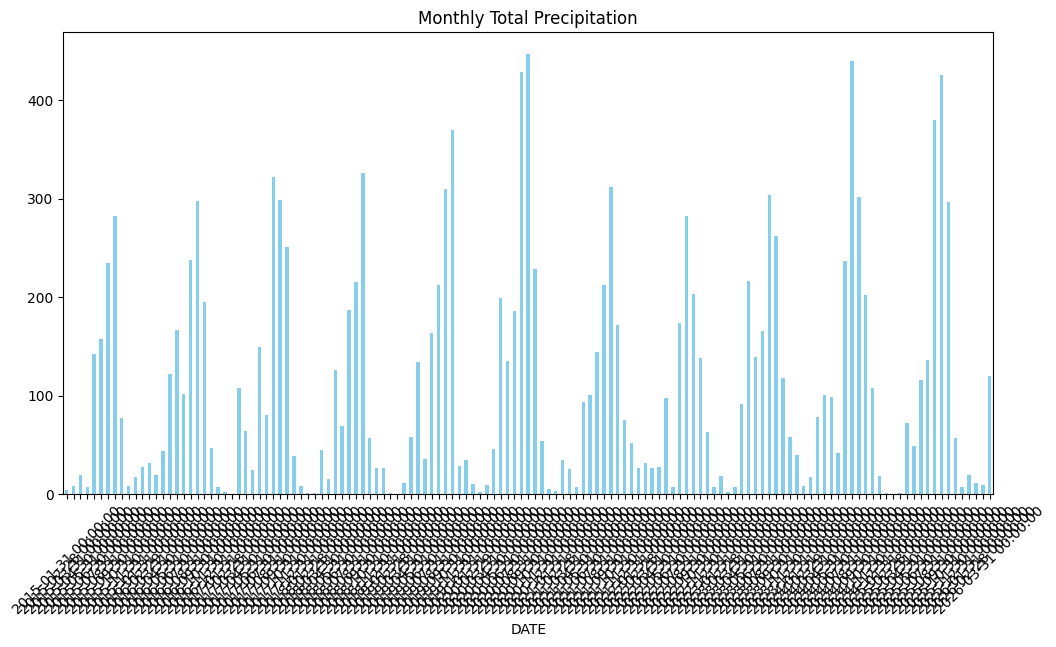

In [19]:
monthly_rain = df.set_index('DATE').resample('ME')['PRECTOTCORR'].sum()

plt.figure(figsize=(12, 6))
monthly_rain.plot(kind='bar', color='skyblue')
plt.title('Monthly Total Precipitation')
plt.xticks(rotation=45)
plt.show()

Monthly total precipitation is analyzed to identify:
- rainy season patterns
- dry periods
- precipitation variability
- potential drought signals

Rainfall variability is one of the most important indicators of agricultural and climate vulnerability in Ethiopia.

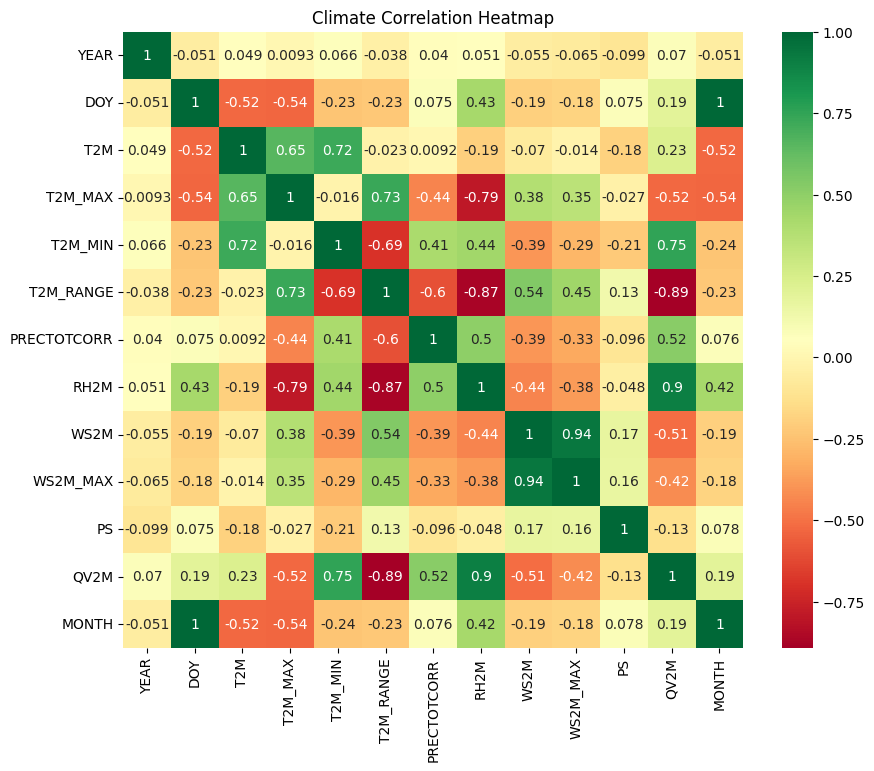

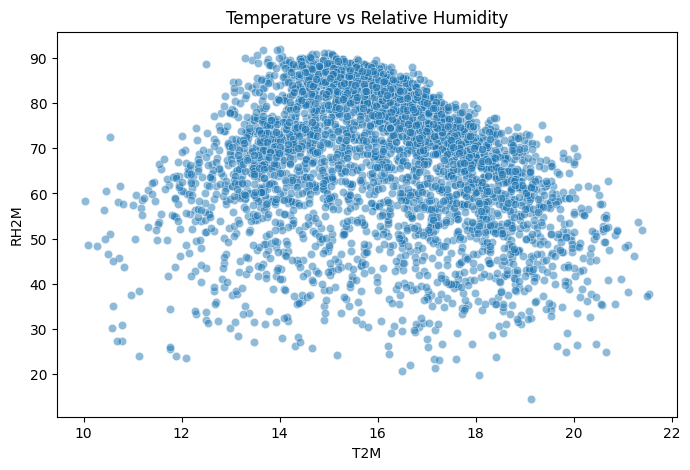

In [20]:
# 1. Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn')
plt.title('Climate Correlation Heatmap')
plt.show()

# 2. Scatter Plot: Temp vs Humidity
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.5)
plt.title('Temperature vs Relative Humidity')
plt.show()

Scatter plots are used to visually explore relationships between:
- Temperature and humidity
- Temperature range and wind speed

These plots help reveal:
- clustering behavior
- trends
- variability
- possible nonlinear relationships

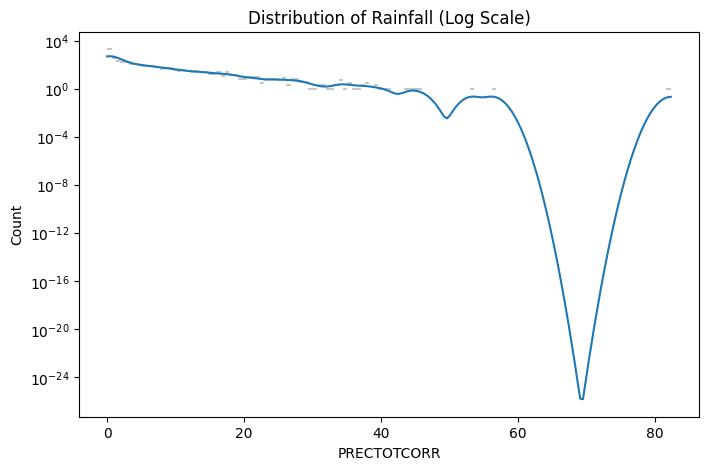

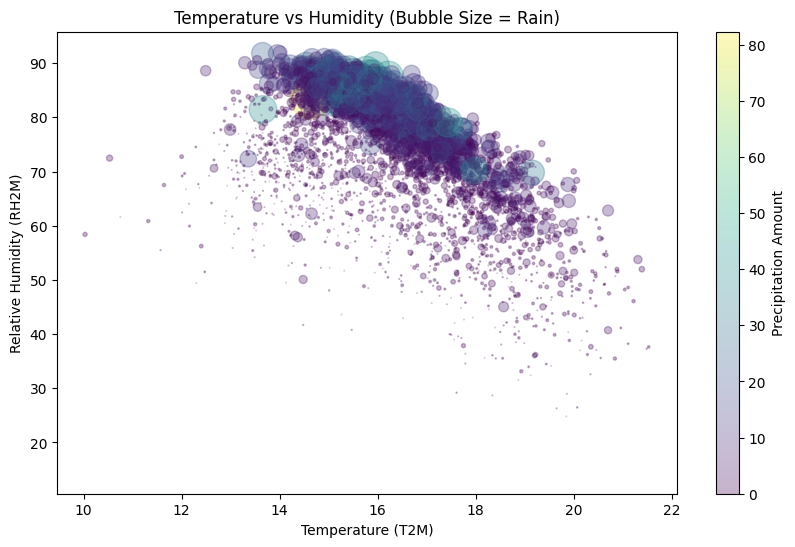

In [21]:
# 1. Log-scale Histogram for Rainfall
plt.figure(figsize=(8, 5))
sns.histplot(df['PRECTOTCORR'], kde=True, log_scale=(False, True)) # Log scale on Y axis
plt.title('Distribution of Rainfall (Log Scale)')
plt.show()

# 2. Bubble Chart: Temp vs Humidity (Size = Rain)
plt.figure(figsize=(10, 6))
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR']*10, alpha=0.3, c=df['PRECTOTCORR'], cmap='viridis')
plt.colorbar(label='Precipitation Amount')
plt.xlabel('Temperature (T2M)')
plt.ylabel('Relative Humidity (RH2M)')
plt.title('Temperature vs Humidity (Bubble Size = Rain)')
plt.show()

The precipitation distribution is examined using histograms.

Climate precipitation data is often highly skewed because:
- many days have little or no rainfall
- extreme rainfall events occur infrequently

Understanding the distribution helps identify climate variability and extreme-event behavior.

The analysis suggests that Ethiopia experiences:
- significant seasonal temperature variability
- uneven precipitation distribution
- periods of elevated climate stress

These trends may have implications for:
- agriculture
- food security
- drought resilience
- water resource management

The findings support the importance of climate adaptation strategies and evidence-based policy discussions ahead of COP32.

The observed warming trends and precipitation variability highlight Ethiopia's vulnerability to climate-related risks.

Potential implications include:
- increased drought frequency
- agricultural instability
- water resource pressure
- heightened adaptation needs


These findings reinforce the importance of:
- climate adaptation financing
- early warning systems
- resilient agricultural planning
- regional climate cooperation

In [2]:
%pip install pandas numpy matplotlib seaborn


^C
Note: you may need to restart the kernel to use updated packages.
